<a href="https://colab.research.google.com/github/DUREKSHA-758/Heart-Disease-Prediction/blob/main/ML_Project_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Required Libraries

In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load Dataset
df = pd.read_csv("/content/drive/My Drive/ML projects/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
print("Shape: ", df.shape)

Shape:  (545, 13)


In [ ]:
print("Columns: ", df.columns.tolist())

Columns:  ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


## Expolatory Data Analysis

In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
# Check missing values
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


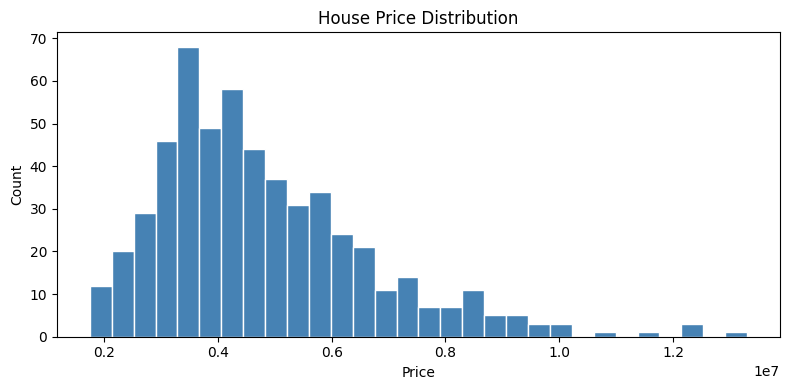

In [ ]:
#plot price distribution
plt.figure(figsize = (8,4))
plt.hist(df['price'], bins= 30, color='steelblue', edgecolor = 'white')
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

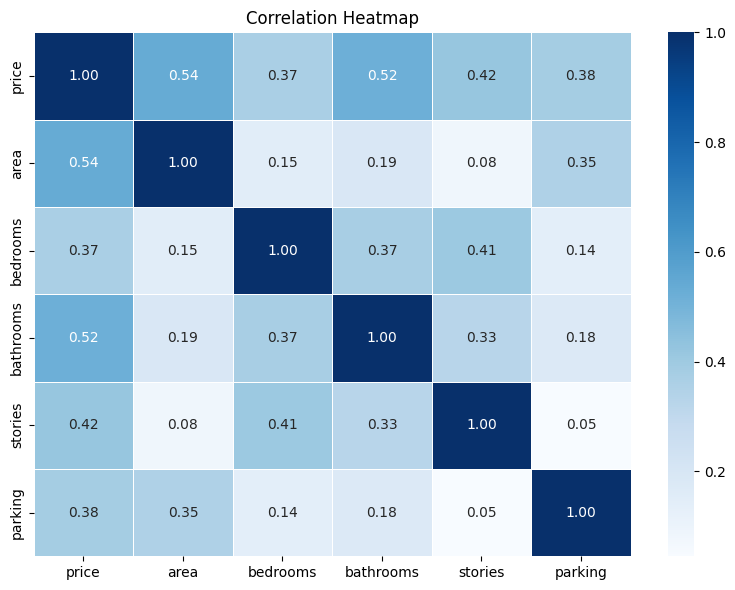

In [ ]:
# Correlation Heatmap(Numeric columns only)
plt.figure(figsize = (8,6))
numeric_df= df.select_dtypes(include = [np.number])
sns.heatmap(numeric_df.corr(), annot = True, fmt = '.2f', cmap = "Blues", linewidth = 0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Preprocessing

In [ ]:
# Load Dataset again to ensure a clean state for preprocessing
df = pd.read_csv("/content/drive/My Drive/ML projects/Housing.csv")

# Convert yes/no columns t0 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
  # Check if the column exists and is of object type (string 'yes'/'no') before replacing
  if col in df.columns and df[col].dtype == 'object':
    df[col] = df[col].replace({'yes':1, 'no': 0})
    df[col] = df[col].astype(int) # Explicitly convert to int

# Convert furnishingstatus to numbers if the column still exists and is of object type
if 'furnishingstatus' in df.columns and df['furnishingstatus'].dtype == 'object':
  df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# Ensure all boolean columns are converted to int (0 or 1)
# This addresses cases where pd.get_dummies might output bools and StandardScaler complains
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

# Fill any remaining NaNs with 0 (or a more appropriate strategy if NaNs were expected)
# This is a safeguard against unexpected NaNs - now unconditional
df.fillna(0, inplace=True)
if df.isnull().sum().sum() > 0:
    print("WARNING: NaN values found after preprocessing. Filling with 0.")

X = df.drop('price', axis = 1)
y = df['price']

print("Feature Shape: ", X.shape)
print("Target Shape: ", y.shape)
print("\nFeature columns: ", X.columns.tolist())

Feature Shape:  (545, 13)
Target Shape:  (545,)

Feature columns:  ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


/tmp/ipykernel_1762/1343390395.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'yes':1, 'no': 0})
/tmp/ipykernel_1762/1343390395.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'yes':1, 'no': 0})
/tmp/ipykernel_1762/1343390395.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('

## Train the Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

print(f"Train Size: {X_train.shape[0]} rows")
print(f"Test Size: {X_test.shape[0]} rows")

Train Size: 436 rows
Test Size: 109 rows


In [ ]:
# Model 1: Linear Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Explicitly replace any NaNs or infinities that might have been introduced by StandardScaler
# due to zero-variance features in the training or test sets.
X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled = np.nan_to_num(X_test_scaled)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


LinearRegression()

In [ ]:
# MOdel 2: Decision Tree
dt_model = DecisionTreeRegressor(random_state = 42, max_depth = 5)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
# Model 3: Random Forest
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Evaluate

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate(name, model, X_t, y_t):
    preds = model.predict(X_t)
    r2   = r2_score(y_t, preds)
    rmse = np.sqrt(mean_squared_error(y_t, preds))
    mae  = mean_absolute_error(y_t, preds)
    print(f"\n{name}")
    print(f"  R² Score : {r2:.4f}")
    print(f"  RMSE     : {rmse:,.0f}")
    print(f"  MAE      : {mae:,.0f}")
    return r2, rmse

r2_lr, _ = evaluate("Linear Regression", lr_model, X_test_scaled, y_test)
r2_dt, _ = evaluate("Decision Tree",     dt_model, X_test,    y_test)
r2_rf, _ = evaluate("Random Forest",     rf_model, X_test,    y_test)


Linear Regression
  R² Score : 0.5590
  RMSE     : 1,493,040
  MAE      : 1,112,059

Decision Tree
  R² Score : 0.4532
  RMSE     : 1,662,425
  MAE      : 1,201,962

Random Forest
  R² Score : 0.5042
  RMSE     : 1,583,008
  MAE      : 1,118,483


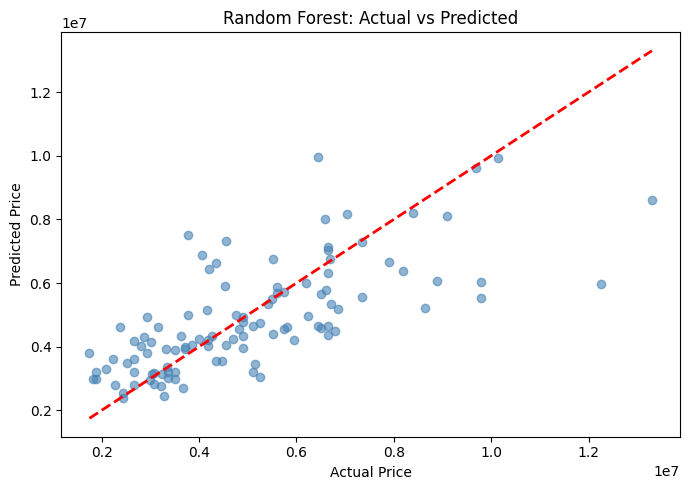

In [ ]:
# Plot: Actual vs Predicted (Random Forest)
rf_preds = rf_model.predict(X_test)
plt.figure(figsize=(7, 5))
plt.scatter(y_test, rf_preds, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted')
plt.tight_layout()
plt.show()

In [ ]:
# Define a new house
new_house = pd.DataFrame({
    'area':              [5000],
    'bedrooms':          [3],
    'bathrooms':         [2],
    'stories':           [2],
    'mainroad':          [1],      # 1 = yes, 0 = no
    'guestroom':         [0],
    'basement':          [1],
    'hotwaterheating':   [0],
    'airconditioning':   [1],
    'parking':           [2],
    'prefarea':          [1],
    'furnishingstatus_semi-furnished': [1],
    'furnishingstatus_unfurnished':    [0],
})

# Make sure columns match training data
new_house = new_house.reindex(columns=X.columns, fill_value=0)

# Predict!
predicted_price = rf_model.predict(new_house)[0]
print(f"Predicted House Price: {predicted_price:,.0f}")

Predicted House Price: 5,291,650
